First time running code will need to install ipywidgets, change below cell from markdown to code and run to install.

!pip install ipywidgets

### Library Imports
##### Cell content description:

##### Changes:
- added ipywidgets and IPython.display lines

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
import math
import numpy as np
import random
from Cell2D import Cell2D
import requests

#new addition:
import ipywidgets as widgets
from IPython.display import display

### airplane_data.xlsx Document Retrieval
##### Cell content description:

In [2]:
file_id = "1bEpF3iwAnaorj-Xl870gB62uqro5arQ3"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"
response = requests.get(url)

with open("airplane_data.xlsx", "wb") as f:
    f.write(response.content)

### Plane Model Selection Menu
##### Cell content description:

##### Changes:
- added plane_dropdown menu widget

In [3]:
# method to read data from excel file
def read_plane_data(file_name):
    df_planes = pd.read_excel(file_name)
    return df_planes

df = read_plane_data('airplane_data.xlsx')

#new additions:
plane_dropdown = widgets.Dropdown(options=[(row['aircraft_type'], idx) for idx, row in df.iterrows()], description='Plane Type:')
display(plane_dropdown)

#removed:
#print('Here are your plane choices:')
#print(df['aircraft_type'])

Dropdown(description='Plane Type:', options=(('A220-300', 0), ('Bombardier CRJ-900', 1), ('Beechcraft 1900D', …

### Selection Grabber and Confirmation Output
##### Changes:
- added plane_type to pull selection from dropdown in above cell
- added print statement to output confirmation of this selection

In [4]:
#added:
plane_choice = plane_dropdown.value

print("Model selected: ", df.loc[plane_choice, 'aircraft_type'])

#removed:
#plane_choice = input("Input the number corresponding to the plane you'd like to simulate:")    

Model selected:  Airbus A320-200 (320)


#### Removed cell:

In [5]:
#removed:
#plane_type = df.loc[int(plane_choice)].at['aircraft_type']
#print('You selected:', plane_type)

### Seat Parameter Initialization

In [6]:
def seat_params_info(df, plane_num):
    """Function to gather information from table regarding seat dimensions and return a list of tuples."""
    seat_width_economy = df.loc[int(plane_num)].at['seat width - economy']
    seat_pitch_economy = df.loc[int(plane_num)].at['seat depth - economy']
    seat_param_economy = seat_width_economy, seat_pitch_economy

    seat_width_business = df.loc[int(plane_num)].at['seat width - business']
    seat_pitch_business = df.loc[int(plane_num)].at['seat depth - business']
    seat_param_business = seat_width_business, seat_pitch_business

    seat_width_1stclass = df.loc[int(plane_num)].at['seat width - first class']
    seat_pitch_1stclass = df.loc[int(plane_num)].at['seat depth - first class']
    seat_param_1stclass = seat_width_1stclass, seat_pitch_1stclass

    seat_params = [seat_param_economy, seat_param_business, seat_param_1stclass]

    return seat_params

### Seat Information Initialization

##### Suggestion:
- combine this function with above seat parameter function?

In [7]:
def num_of_seats_info(df, plane_num):
    """Function to gather information from table regarding number of seats and return a tuple."""
    econ = df.at[int(plane_num), "total seats - economy"]
    bus = df.at[int(plane_num), "total seats - business"]
    first = df.at[int(plane_num), "total seats - first class"]
    
    num_of_seats = econ, bus, first

    return num_of_seats

### Seat Arrangement Initialization
##### Suggestion:
- combine this function with above 2 cells?

In [8]:
def seat_arrange_info(df, plane_num):
    """Function to gather information from table regarding seat arrangement and return a list."""
    seat_arrange_econ = df.loc[int(plane_num)].at['seat arrangement - economy']

    seat_arrange_bus = df.loc[int(plane_num)].at['seat arrangement - business']
    
    seat_arrange_1st = df.loc[int(plane_num)].at['seat arrangement - first class']
    
    seat_arrange = [seat_arrange_econ, seat_arrange_bus, seat_arrange_1st]

    return seat_arrange

In [9]:
print("Seat parameters info:")
print(seat_params_info(df, plane_dropdown.value))

print("\nNumber of seats info:")
print(num_of_seats_info(df, plane_dropdown.value))

print("\nSeat arrangement info:")
print(seat_arrange_info(df, plane_dropdown.value))

Seat parameters info:
[(17.0, 29), (19.0, 32.0), (nan, nan)]

Number of seats info:
(132, 8, 0)

Seat arrangement info:
['3 3', '2 2', nan]


### Seat Class

In [10]:
class Seat:
    def __init__(self, seat_label, class_type, coords, side_of_plane, width):
        self.seat_label = seat_label
        self.letter = seat_label[-1]
        self.row = int(seat_label[:-1])
        self.class_type = class_type
        self.occupied = False
        self.x_coord, self.y_coord = coords
        self.depth = 18
        self.width = width
        self.side_of_plane = side_of_plane

### Plane Class

In [11]:
class Plane:
    def __init__(self, seat_params, num_of_seats, seat_arrange):
        """
        Initialize seat dimensions, number of seats, and arrangement for each class.
        """
        self.seat_param_economy = seat_params[0]
        self.seat_param_business = seat_params[1]
        self.seat_param_firstclass = seat_params[2]

        self.num_of_seats_economy = num_of_seats[0]
        self.num_of_seats_business = num_of_seats[1]
        self.num_of_seats_firstclass = num_of_seats[2]

        self.seat_arrange_economy = seat_arrange[0]
        self.seat_arrange_business = seat_arrange[1]
        self.seat_arrange_firstclass = seat_arrange[2]

        self.seats = []  # List to store all Seat objects

        self.setup_plane_geometry()  # Set up y-coordinates and layout
        self.generate_all_seats()    # Generate all seats across classes

    def generate_seat_labels(self, starting_row, num_of_rows, seats_per_row):
        """Generate seat labels like 1A, 1B... in reverse order"""
        seat_labels = []
        for row in range(starting_row, num_of_rows + starting_row):
            for seat in range(seats_per_row):
                seat_letter = chr(64 + seats_per_row - seat)  # Letters from right to left
                seat_labels.append(f"{row}{seat_letter}")
        return seat_labels[::-1]  # Reverse to match drawing order

    def generate_seats(self, seat_type, starting_row, class_type):
        """Generate Seat objects with layout and positions for a section of the plane."""
        seats_per_col, seats_per_row, num_of_rows, seat_width, leg_room, aisle_gap, start_y = seat_type
        leg_room -= seat_width  # Calculate extra leg space
        seat_depth = 18    # Fixed seat depth

        seat_labels = self.generate_seat_labels(starting_row, num_of_rows, seats_per_row)
        label_index = 0

        y = start_y
        padding = 1
        
        for row in range(num_of_rows):
            x = 0
            
            # Left side seats
            for seat in range(seats_per_col[0]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "left", seat_width))
                label_index += 1
                x += seat_depth + padding

            # Aisle space
            x += aisle_gap

            # Right side seats
            for seat in range(seats_per_col[2]):
                label = seat_labels[label_index]
                self.seats.append(Seat(label, class_type, (x, y), "right", seat_width))
                label_index += 1
                x += seat_depth + padding
            
            y += leg_room + seat_width  # Move down for next row

    def generate_all_seats(self):
        """Reset and generate all seats for all classes."""
        self.seats = []
        y_offset = 0
        starting_row = 1
        reference_params = None  # For aisle alignment
    
        class_sections = [
            ("economy", self.num_of_seats_economy, self.seat_param_economy, self.seat_arrange_economy),
            ("business", self.num_of_seats_business, self.seat_param_business, self.seat_arrange_business),
            ("first", self.num_of_seats_firstclass, self.seat_param_firstclass, self.seat_arrange_firstclass)
        ]
    
        for class_type, num_seats, seat_param, seat_arrange in class_sections:
            # Determine starting row number based on class
            if class_type == "economy":
                starting_row = self.first_class_rows + self.business_class_rows + 1
            elif class_type == "business":
                starting_row = self.first_class_rows + 1
            elif class_type == "first":
                starting_row = 1

            if num_seats > 0:
                draw_inputs = self.get_draw_inputs(seat_param, seat_arrange, num_seats, y_offset, reference_params)
                self.generate_seats(draw_inputs, starting_row, class_type)

                num_rows = draw_inputs[2]
                seat_pitch = draw_inputs[4]
                y_offset += num_rows * seat_pitch  # Update y offset for next class
                starting_row += num_rows

                if not reference_params:
                    reference_params = draw_inputs  # Save reference for alignment

    def find_parameters(self, seat_dims, seat_arrangement, num_of_seats):
        """
        Convert seat config into layout information.
        Returns tuple of seats_per_col, seats_per_row, num_rows, seat_width, leg_room
        """
        seats_per_col = seat_arrangement.split(' ')
        for i, num in enumerate(seats_per_col):
            seats_per_col[i] = int(num)

        dummy_var = seats_per_col[len(seats_per_col)//2]
        seats_per_col[len(seats_per_col)//2] = 0
        seats_per_col.append(dummy_var)

        seats_in_row = sum(seats_per_col)
        num_of_rows = math.ceil(num_of_seats/seats_in_row)

        seat_width = seat_dims[0]
        leg_room = seat_dims[1] 

        return seats_per_col, seats_in_row, num_of_rows, seat_width, leg_room

    def setup_plane_geometry(self):
        """Set class-wise layout and y-offsets"""
        current_y = 0

        # First Class
        if self.num_of_seats_firstclass > 0:
            first_class = self.find_parameters(self.seat_param_firstclass, self.seat_arrange_firstclass, self.num_of_seats_firstclass)
            self.first_class_rows = first_class[2]
            self.first_pitch = first_class[4]
            self.first_class_start_y = current_y
            current_y += self.first_class_rows * self.first_pitch
        else:
            self.first_class_rows = 0
            self.first_pitch = 0
            self.first_class_start_y = 0

        # Business Class
        if self.num_of_seats_business > 0:
            business_class = self.find_parameters(self.seat_param_business, self.seat_arrange_business, self.num_of_seats_business)
            self.business_class_rows = business_class[2]
            self.business_pitch = business_class[4]
            self.business_class_start_y = current_y
            current_y += self.business_class_rows * self.business_pitch
        else:
            self.business_class_rows = 0
            self.business_pitch = 0
            self.business_class_start_y = current_y

        # Economy Class
        economy_class = self.find_parameters(self.seat_param_economy, self.seat_arrange_economy, self.num_of_seats_economy)
        self.economy_seats_in_row = economy_class[1]
        self.economy_rows = economy_class[2]
        self.economy_pitch = economy_class[4]
        self.economy_class_start_y = current_y
        current_y += self.economy_rows * self.economy_pitch

        self.plane_width = economy_class[1] * (18 + 1) + 17  # Estimate full width
        self.plane_length = current_y  # Final total vertical length

    def get_draw_inputs(self, seat_param, seat_arrange, num_of_seats, start_y, reference_params=None, padding=1):
        """Compute drawing parameters for a section and align aisles if needed"""
        params = self.find_parameters(seat_param, seat_arrange, num_of_seats)

        class_width = params[1] * (18 + padding) 
        aisle_gap = self.plane_width - class_width
        return params + (aisle_gap, start_y)

    def draw_seats(self, ax):
        """Draw each seat rectangle on matplotlib axis"""
        self.seats = sorted(self.seats, key=lambda seat: (seat.row, seat.letter))
        for seat in self.seats:
            x, y = seat.x_coord, seat.y_coord
            rect = patches.Rectangle((x, y), seat.depth, seat.width, edgecolor='black', facecolor='lightskyblue')
            ax.add_patch(rect)
            ax.text(x + seat.depth / 2, y + seat.width / 2, seat.seat_label, ha='center', va='center', fontsize=6)

    def draw(self):
        """Initialize and return the figure with drawn seats"""
        fig, ax = plt.subplots()
        self.draw_seats(ax)
        return fig, ax

### Passenger Class
##### Cell content description:
Seat information:
- *seat:* what seat on the plane they will sit in (x and y destination, passengers reach their y (row) value before moving into their assigned seat at x (column) value)
- *current_row_location:* the current vertical position of passenger in simulation, updates for each step until seat row is reached
- *x_pos:* current horizontal location (aisle or seat)
- *y_pos:* current vertical location (row)
    
Passenger information:
- *status:* is the passenger in their assigned seat (do their current *x_pos* and *y_pos* values match the value of *seat*?)
- *emptyseat:* check if the passenger is sitting between and empty seat and the aisle (they will have to get up to let someone occupy an empty seat past them)
- *age:* age of a passenger, weighted chance (impacts *carryon* value)
    - 70% chance 18-54, 20% chance 55-69, 7% chance 70-84, 3% chance 85-99
- *carryon:* boolean value, 80% chance passenger has carryon luggage (carryon = true) that will go in overhead (adds number of steps/model refreshes to *loadingtime*, equal to value of walking speed). 
- *loadingtime:* amount of time it takes a passenger to put away carryon. if passenger carryon is false this value is 0. If carryon = true then loading time is determined by the following (the decided value is how many steps/model refreshes that passenger will stand in the aisle and block the row before others can continue past):
    - 18-54: 60% chance 1, 30% chance 2, 10% chance 3
    - 55-69: 40% chance 1, 40% chance 2, 20% chance 3
    - 70-84: 35% chance 1, 40% chance 2, 35% chance 3
    - 85-99: 20% chance 1, 40% chance 2, 40% chance 3

##### Changes:
- added self.age
- changed self.bag to single line initialization instead of sending to function


##### Notes/Suggestions:
- empty interior seat boolean, if the passenger is seated but they are between an empty seat and an aisle they will need to move from the seat before that passenger can sit
- everyone walks one step per frame, loading time is taken while in seat row before moving into seat

In [12]:
class Passenger:
    def __init__(self, seat):
        #seat information:
        self.seat = seat
        self.current_row_location = 0 # y-position in aisle
        self.x_pos = 0
        self.y_pos = 0

        #passenger information:
        self.status = "not seated"
        self.emptyseat = False
        self.bag = random.random() < 0.8
    #added:
        self.age = generate_age()
        self.carryon = 0 if random.random() < 0.2 else random.choice([1, 2, 3]) 
            #^ uses the 80% of people have carry on bag
            #^describes having carryon luggage that goes in overhead
        self.stuff = random.randint(0,3)
        if self.bag:
            self.loadingtime = generate_loadingtime(self.age)
            #^if passenger has bag we generate loading time
        else:
            self.loadingtime = 0;
        
    #removed:
        #self.speed = generate_speed

    #def has_bag(self):
        # https://www.theatlantic.com/technology/archive/2024/02/airplane-carry-on-luggage-crisis-conspiracy/677452/
        # approximately 80% of people bring a carry on bag
        #return 

added entire cell: function for age initialization

In [13]:
def generate_age():
    # Generate age for adult passengers based on desired percentages
    categories = [
        ("18-54", 70, (18, 54)),
        ("55-69", 20, (55, 69)),
        ("70-84", 7, (70, 84)),
        ("85-99", 3, (85, 99))
    ]
    total_weight = sum(weight for (_, weight, _) in categories)
    r = random.uniform(0, total_weight)
    upto = 0
    for label, weight, (low, high) in categories:
        if upto + weight >= r:
            return random.randint(low, high)
        upto += weight
    return random.randint(18, 99)

added entire cell: function for loadingtime intialization

In [14]:
def generate_loadingtime(age):
    if 18 <= age <= 54:
        weights = [0.60, 0.30, 0.10]
    elif 55 <= age <= 69:
        weights = [0.40, 0.40, 0.20]
    elif 70 <= age <= 84:
        weights = [0.35, 0.40, 0.35]
    elif 85 <= age <= 99:
        weights = [0.20, 0.40, 0.40]
    else:
        weights = [0.33, 0.33, 0.34]
    return random.choices([1, 2, 3], weights=weights, k=1)[0]

added entire cell: update emptyseat function
Update the emptyseat attribute after the passenger has been seated. If the passenger is in a seat furthest from the aisle (i.e. a window seat) then emptyseat remains False. Otherwise, if the seat is between the aisle and another seat, then the method checks the occupancy of the adjacent (aisle) seat provided via the optional parameter. If the adjacent seat is empty, emptyseat is set to True indicating that when that passenger begins unloading (putting away their bag), this passenger should move into the aisle, allowing passage.


Update the emptyseat attribute using the plane seat layout. For the passenger’s cabin, this method uses the seating configuration provided by seat_arrange_info (which is a string like "3 3" for economy or "2 2" for business) to derive the full row and assign letters consecutively starting with "A". Then:
- If the passenger is in the window seat (i.e. left side: first letter; right side: last letter in the full row), emptyseat is set to False.
- Otherwise, determine the adjacent seat toward the window:
    - For left-side passengers, that is the seat with the immediately preceding letter.
    - For right-side passengers, that is the seat with the immediately following letter.
- Look up that adjacent seat in the global plane (assumed to be in current_plane.seats) to check its occupancy.
- If the adjacent seat is unoccupied, then emptyseat is set to True (indicating the passenger should get up to allow passage when the other passenger begins unloading). Otherwise, emptyseat remains False.

In [15]:
def update_emptyseat(self):
        # This method only applies once the passenger is seated.
        if self.status != "seated":
            return

        # Obtain the seating arrangement for this passenger’s cabin:
        class_type = self.seat.class_type.lower()
        arrangements = seat_arrange_info(df, plane_dropdown.value)  # global layout info
        if class_type == "economy":
            arrangement_str = arrangements[0]
        elif class_type == "business":
            arrangement_str = arrangements[1]
        elif class_type in ["first", "first class"]:
            arrangement_str = arrangements[2]
        else:
            arrangement_str = None

        if arrangement_str is None or (isinstance(arrangement_str, float) and pd.isna(arrangement_str)):
            self.emptyseat = False
            return

        try:
            left_count, right_count = map(int, arrangement_str.split())
        except Exception:
            self.emptyseat = False
            return

        full_row_seats = left_count + right_count

        # Generate full row letters, e.g. for 6 seats: ['A', 'B', 'C', 'D', 'E', 'F']
        row_letters = [chr(ord('A') + i) for i in range(full_row_seats)]
        
        # Determine the passenger's position in the full row from their seat letter.
        if self.seat.letter in row_letters:
            pos = row_letters.index(self.seat.letter)
        else:
            # If the seat letter is not found, default to not emptying the seat.
            self.emptyseat = False
            return

        # Depending on the side of the plane, determine the adjacent seat toward the window.
        if self.seat.side_of_plane.lower() == "left":
            # For left side, the window seat is the first one (position 0).
            if pos == 0:
                self.emptyseat = False  # Already a window seat.
            else:
                # The adjacent seat toward the window is at position pos - 1.
                adjacent_letter = row_letters[pos - 1]
                adjacent_seat_label = f"{self.seat.row}{adjacent_letter}"
                # Search for the adjacent seat in the current plane's seat list.
                adjacent_seat = None
                for s in current_plane.seats:  # global current_plane assumed
                    if s.seat_label == adjacent_seat_label:
                        adjacent_seat = s
                        break
                if adjacent_seat is not None and adjacent_seat.occupied:
                    self.emptyseat = False
                else:
                    self.emptyseat = True

        elif self.seat.side_of_plane.lower() == "right":
            # For right side, the window seat is the last seat in the full row.
            if pos == full_row_seats - 1:
                self.emptyseat = False  # Window seat.
            else:
                # The adjacent seat toward the window is the seat with the next letter.
                adjacent_letter = row_letters[pos + 1]
                adjacent_seat_label = f"{self.seat.row}{adjacent_letter}"
                adjacent_seat = None
                for s in current_plane.seats:  # global current_plane assumed
                    if s.seat_label == adjacent_seat_label:
                        adjacent_seat = s
                        break
                if adjacent_seat is not None and adjacent_seat.occupied:
                    self.emptyseat = False
                else:
                    self.emptyseat = True

        else:
            self.emptyseat = False

added entire cell: example passenger generation

def generate_examplePassengers(n=10):
    dummy_seat = Seat("1A", "economy", (0, 0), "left", 18)
    passengers = [Passenger(dummy_seat) for _ in range(n)]
    return passengers

def display_passengers(passengers):
    import pandas as pd
    passenger_data = []
    for i, p in enumerate(passengers):
        # Use the seat_label attribute if available; otherwise, mark as N/A
        seat_label = p.seat.seat_label if hasattr(p.seat, 'seat_label') else "N/A"
        passenger_data.append({
            "Passenger": i + 1,
            "Seat": seat_label,
            "Status": p.status,
            "Bag": p.bag,
            "Age": p.age,
            "Carryon": p.carryon,
            "Stuff": p.stuff,
            "Loading Time": p.loadingtime
        })
    df_passengers = pd.DataFrame(passenger_data)
    print(df_passengers)

# Generate 10 example passengers and display their attributes
example_passengers = generate_examplePassengers(10)
display_passengers(example_passengers)

In [16]:
    def move(self, passenger, prev_position, prev_status, prev_speed):
        if passenger.status == "not seated":
            if passenger.current_row_location < passenger.seat.row:
                can_move = False
            
                if prev_position is None:  # No one in front
                    can_move = True
                elif prev_speed != 0:
                    can_move = True
                elif prev_speed == 0 and prev_status == "seated":
                    can_move = True
                elif prev_speed == 0 and prev_status == "unloading":
                    can_move = False
    
                if can_move:
                    # change speed based on location in plane so move one seat forward each time
                    if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                        passenger.speed = self.plane.first_pitch
                    elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                        passenger.speed = self.plane.business_pitch
                    else:
                        passenger.speed = self.plane.economy_pitch
                    
                    passenger.y_pos -= passenger.speed
                    passenger.current_row_location += 1
    
            elif passenger.current_row_location == passenger.seat.row and passenger.status == "not seated":
                passenger.speed = 0
                passenger.status = "unloading"

            elif passenger.current_row_location == passenger.seat.row and passenger.status == "unloading":
                if passenger.seat.side_of_plane == "left":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth/2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width/2
                    
                elif passenger.seat.side_of_plane == "right":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth/2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width/2
            
                passenger.status = "seated"
                passenger.seat.occupied = True
                # ADD!!!! check if other people are in the row and have to get out for you to get to your seat


In [17]:
class PlaneBoarding(Cell2D):
    def __init__(self, num_of_passengers, plane, boarding_method, constructor=Passenger):
        self.plane = plane
        self.passengers = []
        num_of_passengers = int(num_of_passengers)
        
        if self.plane.num_of_seats_firstclass > 0:
            largest_pitch = self.plane.first_pitch
        elif self.plane.num_of_seats_business > 0:
            largest_pitch = self.plane.business_pitch
        else:
            largest_pitch = self.plane.economy_pitch
        
        booked_seats = random.sample([seat for seat in self.plane.seats], num_of_passengers)
        
        # Create start positions just outside the plane
        self.passengers = [constructor(seat) for seat in booked_seats]

        # make method to call boarding/seating method here     
        self.passengers = self.select_boarding_method(boarding_method)

        for i, passenger in enumerate(self.passengers):
            passenger.current_row_location = -i
            passenger.x_pos = self.plane.plane_width/2
            passenger.y_pos = self.plane.plane_length + (i+1) * largest_pitch
    
    def find_coords(self, passengers):
        x_coords = np.array([(passenger.x_pos) for passenger in passengers])
        y_coords = np.array([(passenger.y_pos) for passenger in passengers])
        
        return x_coords, y_coords

    def select_boarding_method(self, boarding_method_num):
        # need first class/business class passengers at top of list so they get seated first
        priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type in ["business", "first"]]
        
        # make list of all passengers not in first class - pass this to other functions to sort/put in specific order for boarding
        non_priority_passengers = [passenger for passenger in self.passengers if passenger.seat.class_type == "economy"]

        # TODO: finish this method with group during meeting!!!
        if boarding_method_num == 0:
            # call random method
            return priority_passengers + self.random_boarding(non_priority_passengers)
        #elif boarding_method_num == 1:
            # call boarding method 1's method
            
        #elif boarding_method_num == 2:
            # call boarding method 2's method
            
        #elif boarding_method_num == 3:
            # call boarding method 3's method
        else:
            return priority_passengers + non_priority_passengers

    def random_boarding(self, econ_passengers):
        random.shuffle(econ_passengers)
        return econ_passengers
        
    def step(self):
        positions_before = [p.current_row_location for p in self.passengers]
    
        for i, passenger in enumerate(self.passengers):
            previous_position = positions_before[i - 1] if i > 0 else None
            previous_status = self.passengers[i - 1].status if i > 0 else None
            previous_speed = self.passengers[i - 1].speed if i > 0 else None
    
            self.move(passenger, previous_position, previous_status, previous_speed)

    def all_passengers_seated(self):
        return all(passenger.status == "seated" for passenger in self.passengers)
    
    def move(self, passenger, prev_position, prev_status, prev_speed):
        if passenger.status == "not seated":
            if passenger.current_row_location < passenger.seat.row:
                can_move = False
    
                if prev_position is None:  # No one in front
                    can_move = True
                elif prev_speed != 0:
                    can_move = True
                elif prev_speed == 0 and prev_status == "seated":
                    can_move = True
                elif prev_speed == 0 and prev_status == "unloading":
                    can_move = False  # Wait behind someone unloading their bag
    
                if can_move:
                    # Determine pitch based on section
                    if passenger.current_row_location <= self.plane.first_class_rows and self.plane.first_class_rows != 0:
                        passenger.speed = self.plane.first_pitch
                    elif passenger.current_row_location <= self.plane.business_class_rows and self.plane.business_class_rows != 0:
                        passenger.speed = self.plane.business_pitch
                    else:
                        passenger.speed = self.plane.economy_pitch
    
                    # Move forward one row
                    passenger.y_pos -= passenger.speed
                    passenger.current_row_location += 1
    
            elif passenger.current_row_location == passenger.seat.row:
                # Stop to unload bag
                passenger.speed = 0
                passenger.status = "unloading"
    
                # Add delay counter if not already set
                if not hasattr(passenger, "bag_delay"):
                    passenger.bag_delay = 2 if passenger.has_bag else 0  # Delay only if they have a bag
    
        elif passenger.status == "unloading":
            if passenger.bag_delay > 0:
                passenger.bag_delay -= 1  # Wait while unloading
            else:
                # Now move to seat and be seated
                if passenger.seat.side_of_plane == "left":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
    
                elif passenger.seat.side_of_plane == "right":
                    passenger.x_pos = passenger.seat.x_coord + passenger.seat.depth / 2
                    passenger.y_pos = passenger.seat.y_coord + passenger.seat.width / 2
    
                passenger.status = "seated"
                passenger.seat.occupied = True
        
    def draw(self):
        fig, ax = self.plane.draw()
        x_coords, y_coords = self.find_coords(self.passengers)

        for passenger, x, y in zip(self.passengers, x_coords, y_coords):
            person = patches.Circle((x, y), radius=6, edgecolor='black', facecolor='salmon')
            ax.add_patch(person)

            if passenger.bag:
                bag = patches.Rectangle((x + 5, y-2), width=2, height=4, color='brown')
                ax.add_patch(bag)

        fig.set_size_inches((self.plane.plane_width + 5) * 0.025, (self.plane.plane_length) * 0.025)

        ax.set_xlim(0, self.plane.plane_width + 5)
        ax.set_ylim(0, self.plane.plane_length)  
        ax.set_aspect('equal')
        ax.set_autoscale_on(False)

        plt.axis('equal')
        plt.axis('off')
        plt.show()

In [18]:
plane = Plane(seat_params_info(df, plane_choice), num_of_seats_info(df, plane_choice), seat_arrange_info(df, plane_choice))

print(f"There are {len(plane.seats)} seats on the plane.")

There are 140 seats on the plane.


In [19]:
num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

while int(num_of_passengers) > len(plane.seats):
    print(f"Please input a number less than or equal to {len(plane.seats)}.")
    num_of_passengers = input("How many passengers would you like to simulate (aka. board the plane)?")

How many passengers would you like to simulate (aka. board the plane)? 140


In [20]:
boarding_dropdown = widgets.Dropdown(
    options=[
        ("Random Method", 0),
        ("INPUT METHOD 1 HERE", 1),
        ("INPUT METHOD 2 HERE", 2),
        ("INPUT METHOD 3 HERE", 3),
        ("INPUT METHOD 4 HERE", 4)
    ],
    description="Boarding Method:"
)
display(boarding_dropdown)

Dropdown(description='Boarding Method:', options=(('Random Method', 0), ('INPUT METHOD 1 HERE', 1), ('INPUT ME…

In [21]:
boarding_choice = boarding_dropdown.value

selected_label = next(label for label, value in boarding_dropdown.options if value == boarding_choice)
print("Selected boarding method:", selected_label)

Selected boarding method: Random Method


In [22]:
def run_simulation(boarding):
    steps = 0
    while not boarding.all_passengers_seated():
        boarding.step()
        steps += 1

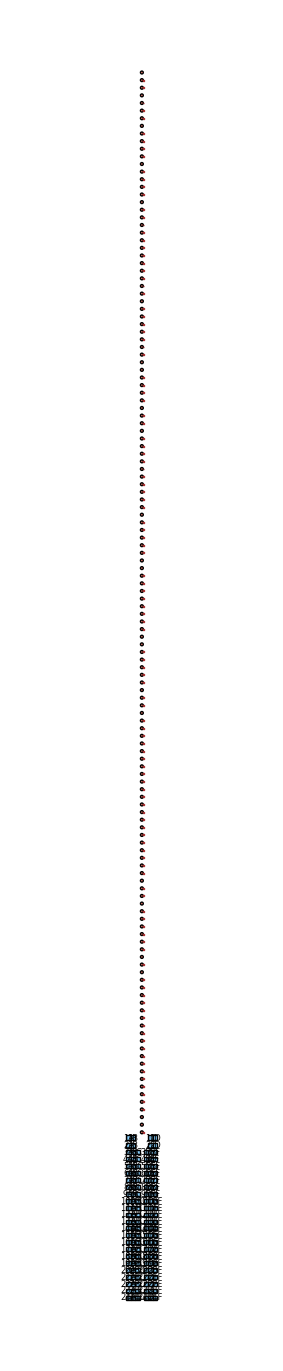

AttributeError: 'Passenger' object has no attribute 'has_bag'

In [23]:
plane_boarding = PlaneBoarding(num_of_passengers, plane, boarding_choice, Passenger)
plane_boarding.animate(frames=10, interval=1)